# Estimación de compensaciones en el sector tecnológico

**Cuaderno reproducible de la tesis**

Universidad ESAN · Facultad de Ingeniería · Carrera de Ingeniería de Sistemas

Arian Antonio Garay Concha · Carlos Sebastián Ramos Flores

---

Este cuaderno reproduce el experimento completo del Capítulo IV. Llama a los mismos
módulos que los scripts del proyecto, de modo que no existe una implementación
alternativa que pueda divergir de la documentada.

**Requisitos previos:** entorno con las dependencias de `requirements.txt`. Los datos
se descargan automáticamente del repositorio oficial de Stack Overflow (licencia
ODbL 1.0) la primera vez que se ejecuta.

**Duración aproximada:** 8 minutos.

**Semilla:** 42, fijada en partición, inicialización de modelos y remuestreo.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 42
np.random.seed(SEMILLA)
print("Raíz del proyecto:", RAIZ)

Raíz del proyecto: /home/debugsito/Documents/local/tesis/tech-salary-prediction


## 1. Carga y preparación de los datos

El módulo de carga aplica los criterios de inclusión documentados en §3.2.4 y
devuelve, junto al conjunto resultante, el registro del efecto de cada filtro sobre
el tamaño muestral. Ese registro es el que alimenta la tabla del Capítulo IV: no se
transcribe a mano.

In [2]:
from src.data_loader_stackoverflow import cargar_encuesta, TARGET

df, registro = cargar_encuesta(anio="2023")
registro

,paso,criterio,n,descartados
0,0,Respuestas totales de la edición,89184,0
1,1,Reporta compensación anual,48019,41165
2,2,Situación de empleo: asalariado,43776,4243
3,3,Desarrollador profesional,40410,3366
4,4,País con al menos 30 observaciones,39682,728
5,5,"Compensación dentro de [0.2, 6] veces la media...",37964,1718
6,6,Coherencia entre años declarados y tramo de edad,37622,342


In [3]:
print(f"Muestra efectiva: {len(df):,} observaciones × {df.shape[1]} columnas")
print(f"Países: {df['Country'].nunique()}")
print(f"Mediana: ${df[TARGET].median():,.0f}   ·   Media: ${df[TARGET].mean():,.0f}")
print(f"Asimetría: {df[TARGET].skew():.2f}   ·   tras logaritmo: {df['salary_log'].skew():.2f}")

Muestra efectiva: 37,622 observaciones × 133 columnas
Países: 78
Mediana: $78,175   ·   Media: $96,319
Asimetría: 2.56   ·   tras logaritmo: -0.82


### 1.1 Distribución de la variable dependiente

La transformación logarítmica reduce la asimetría e invierte su signo. El valor
residual de −0.82 implica que el supuesto de normalidad de los residuos se cumple de
forma aproximada y no exacta, extremo que se declara en §4.1.3.

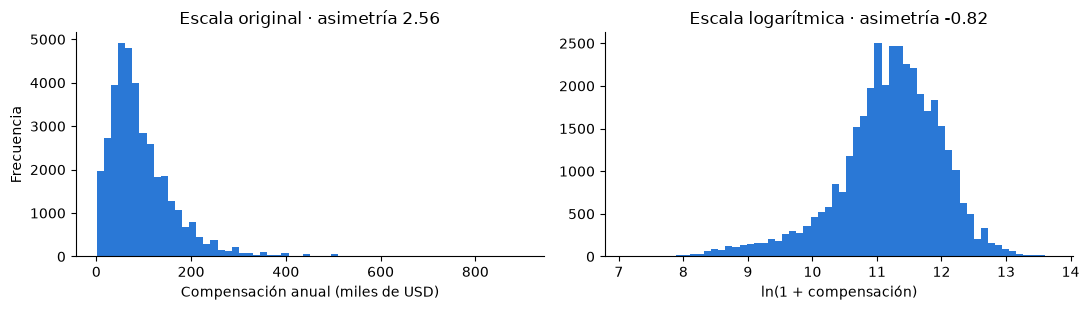

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
a1.hist(df[TARGET] / 1000, bins=60, color="#2a78d6")
a1.set(xlabel="Compensación anual (miles de USD)", ylabel="Frecuencia",
       title=f"Escala original · asimetría {df[TARGET].skew():.2f}")
a2.hist(df["salary_log"], bins=60, color="#2a78d6")
a2.set(xlabel="ln(1 + compensación)",
       title=f"Escala logarítmica · asimetría {df['salary_log'].skew():.2f}")
for a in (a1, a2):
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 1.2 Composición de la muestra

El 85 % de las observaciones corresponde a países de renta alta. Esta representación
desigual condiciona la potencia del análisis de equidad para las regiones de menor
renta, y se declara como limitación en §6.2.1.

In [5]:
comp = (df.groupby("income_group", observed=True)[TARGET]
        .agg(N="count", mediana="median")
        .assign(pct=lambda t: (t.N / len(df) * 100).round(1))
        .sort_values("mediana", ascending=False))
comp

,N,mediana,pct
income_group,,,
High income,32027,86743.0,85.1
Upper middle income,3578,33757.5,9.5
Lower middle income,2017,16964.0,5.4


## 2. Diseño experimental

Diseño factorial entre estrategia de representación de variables categóricas de alta
cardinalidad y arquitectura de modelado, evaluado sobre particiones idénticas para
que la comparación admita contraste pareado.

**Nota sobre el número de repeticiones.** La validación cruzada se repite cuatro
veces. El motivo no es aumentar la potencia sino hacer posible el contraste: la
prueba de Wilcoxon con cinco pares tiene un valor *p* mínimo alcanzable de 0.0625,
superior al nivel de significación de 0.05. Con solo cinco particiones ninguna
hipótesis podría aceptarse, con independencia de los datos.

In [6]:
from scipy.stats import wilcoxon

for n in (5, 10, 20):
    x = np.arange(n, dtype=float)
    print(f"n = {n:>3} pares  →  valor p mínimo alcanzable = {wilcoxon(x, x + 1).pvalue:.6f}")

n =   5 pares  →  valor p mínimo alcanzable = 0.062500
n =  10 pares  →  valor p mínimo alcanzable = 0.001953
n =  20 pares  →  valor p mínimo alcanzable = 0.000008


In [7]:
from src.feature_pipeline_so import preparar_xy, construir_preprocesador
from src.model_registry import build_models
from sklearn.model_selection import train_test_split

X, y, A = preparar_xy(df)
X_ent, X_pru, y_ent, y_pru, A_ent, A_pru = train_test_split(
    X, y, A, test_size=0.20, random_state=SEMILLA, stratify=df["income_group"])

print(f"Predictores: {X.shape[1]}")
print(f"Entrenamiento: {len(X_ent):,}   ·   Prueba: {len(X_pru):,}")
print(f"Modelos disponibles: {', '.join(build_models())}")

Predictores: 119
Entrenamiento: 30,097   ·   Prueba: 7,525
Modelos disponibles: Ridge, HistGradientBoosting, XGBoost, LightGBM, CatBoost


## 3. Entrenamiento y evaluación

La ejecución completa se delega al script del proyecto, que exporta todos los
artefactos. Reproducirla aquí duplicaría la lógica y abriría la posibilidad de que
ambas versiones divergiesen.

In [8]:
# Descomentar para reejecutar el experimento completo (unos 4 minutos).
# import subprocess
# subprocess.run([sys.executable, "scripts/run_experiment.py"], cwd=RAIZ, check=True)

cv = pd.read_csv(RAIZ / "results/cv_by_encoding.csv")
resumen = (cv.groupby(["modelo", "codificacion"])[["R2", "MAE_log", "MAE_USD"]]
           .agg(["mean", "std"]).round(4))
resumen.sort_values(("R2", "mean"), ascending=False)

R2         MAE_log             MAE_USD  \
                                     mean     std    mean     std        mean   
modelo               codificacion                                               
XGBoost              target        0.7863  0.0066  0.2743  0.0032  24889.7242   
CatBoost             target        0.7857  0.0065  0.2747  0.0031  24899.3447   
LightGBM             onehot        0.7854  0.0061  0.2749  0.0033  24898.0768   
                     target        0.7845  0.0066  0.2755  0.0031  24947.0030   
CatBoost             onehot        0.7830  0.0064  0.2766  0.0033  25084.2718   
XGBoost              onehot        0.7822  0.0066  0.2769  0.0037  25120.2116   
HistGradientBoosting target        0.7818  0.0066  0.2774  0.0032  25157.6593   
                     onehot        0.7815  0.0065  0.2776  0.0036  25156.1600   
Ridge                onehot        0.7544  0.0064  0.2978  0.0035  26773.3657   
                     target        0.7506  0.0069  0.3006  0.0034  26921.3343   
Baseline_media       onehot       -0.0001  0.0002  0.6122  0.0069  50412.6660   
                     target       -0.0001  0.0002  0.6122  0.0069  50412.6660   
Baseline_mediana     onehot       -0.0075  0.0020  0.6093  0.0068  50198.0256   
                     target       -0.0075  0.0020  0.6093  0.0068  50198.0256   

                                             
                                        std  
modelo               codificacion            
XGBoost              target        473.0681  
CatBoost             target        474.2099  
LightGBM             onehot        497.5389  
                     target        479.1366  
CatBoost             onehot        521.7453  
XGBoost              onehot        509.7706  
HistGradientBoosting target        492.0864  
                     onehot        506.4189  
Ridge                onehot        504.2509  
                     target        477.5561  
Baseline_media       onehot        851.3985  
                     target        851.3985  
Baseline_mediana     onehot        823.0128  
                     target        823.0128

## 4. Contraste de hipótesis

Los contrastes se agrupan en familias, cada una asociada a la hipótesis que responde.
Comparar todas las configuraciones entre sí obligaría a una corrección por
comparaciones múltiples tan severa que ninguna diferencia real alcanzaría
significación, y además incluiría comparaciones que no responden a ninguna hipótesis.

In [9]:
w = pd.read_csv(RAIZ / "results/wilcoxon_tests.csv")
w = w[w.metrica == "R2"]

print("HE1 — estrategia de codificación, a igualdad de modelo\n")
he1 = w[w.familia == "HE1_codificacion"]
print(he1[["config_a", "config_b", "media_a", "media_b",
           "diferencia", "p_valor", "significativo"]].to_string(index=False))

HE1 — estrategia de codificación, a igualdad de modelo

                   config_a                    config_b  media_a  media_b  diferencia  p_valor  significativo
            CatBoost/target             CatBoost/onehot   0.7857   0.7830      0.0027 0.000002           True
               Ridge/target                Ridge/onehot   0.7506   0.7544     -0.0039 0.000002           True
             XGBoost/target              XGBoost/onehot   0.7863   0.7822      0.0040 0.000002           True
            LightGBM/target             LightGBM/onehot   0.7845   0.7854     -0.0008 0.097307          False
HistGradientBoosting/target HistGradientBoosting/onehot   0.7818   0.7815      0.0004 0.368277          False


In [10]:
print("Modelo lineal frente a ensamblados\n")
lin = w[w.familia == "lineal_vs_ensamblado"]
print(lin[["config_a", "config_b", "diferencia", "p_valor", "significativo"]].to_string(index=False))

hg = w[w.familia == "HG_vs_baseline"]
print(f"\nHG — superioridad sobre la línea base: "
      f"{hg.significativo.sum()}/{len(hg)} significativas, p máximo {hg.p_valor.max():.2e}")

Modelo lineal frente a ensamblados

    config_a                    config_b  diferencia  p_valor  significativo
Ridge/onehot             CatBoost/onehot     -0.0286 0.000002           True
Ridge/onehot HistGradientBoosting/onehot     -0.0270 0.000002           True
Ridge/onehot             LightGBM/onehot     -0.0310 0.000002           True
Ridge/onehot              XGBoost/onehot     -0.0278 0.000002           True
Ridge/target             CatBoost/target     -0.0352 0.000002           True
Ridge/target HistGradientBoosting/target     -0.0313 0.000002           True
Ridge/target             LightGBM/target     -0.0340 0.000002           True
Ridge/target              XGBoost/target     -0.0357 0.000002           True

HG — superioridad sobre la línea base: 20/20 significativas, p máximo 1.91e-06


## 5. Explicabilidad

Se emplea el algoritmo específico para modelos de árbol. El estimador basado en
núcleo resultaría impracticable sobre una muestra de esta magnitud.

Los valores calculados se conservan como artefacto y no solo las figuras derivadas,
para permitir su verificación independiente.

In [11]:
shap_res = pd.read_csv(RAIZ / "results/shap_summary_XGBoost_target_2023.csv")
top = shap_res.head(10)[["variable", "shap_medio_abs", "ic_inferior", "ic_superior"]]
top.round(4)

,variable,shap_medio_abs,ic_inferior,ic_superior
0,Country,0.4223,0.4154,0.4299
1,YearsCodePro_num,0.1583,0.1561,0.1605
2,income_group_High income,0.0461,0.0450,0.0473
3,DevType,0.0387,0.0379,0.0395
4,"OrgSize_10,000 or more employees",0.0361,0.0352,0.0369
5,YearsCode_num,0.0322,0.0316,0.0328
6,language__php,0.0308,0.0302,0.0315
7,platform__amazon_web_services_(aws),0.0302,0.0300,0.0303
8,RemoteWork_Remote,0.0239,0.0237,0.0242
9,language__typescript,0.0223,0.0221,0.0224


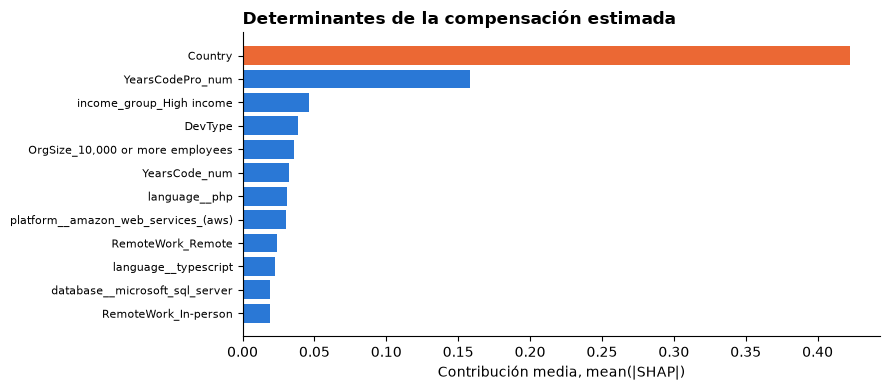

El país aporta 2.7 veces más que los años de experiencia profesional.


In [12]:
t = shap_res.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4))
colores = ["#eb6834" if v == "Country" else "#2a78d6" for v in t.variable]
ax.barh(range(len(t)), t.shap_medio_abs, color=colores)
ax.set_yticks(range(len(t)))
ax.set_yticklabels([v[:38] for v in t.variable], fontsize=8)
ax.set_xlabel("Contribución media, mean(|SHAP|)")
ax.set_title("Determinantes de la compensación estimada", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

pais = float(shap_res.loc[shap_res.variable == "Country", "shap_medio_abs"].iloc[0])
exp = float(shap_res.loc[shap_res.variable == "YearsCodePro_num", "shap_medio_abs"].iloc[0])
print(f"El país aporta {pais/exp:.1f} veces más que los años de experiencia profesional.")

## 6. Auditoría de equidad

**Precisión determinante.** El error absoluto no es comparable entre grupos con
niveles salariales dispares, y su uso conduce a la conclusión contraria a la
correcta. La celda siguiente lo muestra.

In [13]:
import json
aud = json.loads((RAIZ / "results/fairness_income_group_2023.json").read_text())

filas = [{"grupo": g, "N": v["n"],
          "MAE": round(v["mae"]),
          "mediana": round(v["mediana_real"]),
          "MAE/mediana": f"{v['mae_relativo']*100:.1f} %",
          "sesgo": round(v["sesgo_sistematico"])}
         for g, v in aud["por_grupo"].items()]
tabla = pd.DataFrame(filas).sort_values("MAE", ascending=False)
print(tabla.to_string(index=False))

a = aud["agregados"]
print(f"\nRazón de disparidad ABSOLUTA: {a['razon_disparidad_absoluta']:.2f}"
      f"  →  peor servido: {a['grupo_peor_servido_absoluto']}")
print(f"Razón de disparidad RELATIVA: {a['razon_disparidad_relativa']:.2f}"
      f"  →  peor servido: {a['grupo_peor_servido_relativo']}")
print(f"\n¿La conclusión se invierte al normalizar? {a['invierte_al_normalizar']}")

              grupo    N   MAE  mediana MAE/mediana  sesgo
        High income 6406 26286    88173      29.8 %  -5640
Upper middle income  716 17688    34350      51.5 %  -7097
Lower middle income  403  9846    16964      58.0 %  -5423

Razón de disparidad ABSOLUTA: 2.67  →  peor servido: High income
Razón de disparidad RELATIVA: 1.95  →  peor servido: Lower middle income

¿La conclusión se invierte al normalizar? True


### 6.1 Género: la desigualdad del mercado no es sesgo del modelo

La edición 2022 es la última cuya versión pública incluye la variable de género:
Stack Overflow la retiró de sus conjuntos públicos a partir de 2023.

In [14]:
gen = json.loads((RAIZ / "results/fairness_Gender_2022.json").read_text())
for g in ("Man", "Woman", "Non-binary, genderqueer, or gender non-conforming"):
    if g in gen["por_grupo"]:
        v = gen["por_grupo"][g]
        print(f"{g[:32]:34s} N={v['n']:>5,}  error relativo {v['mae_relativo']*100:.1f} %")

c = gen["contrastes"]
print(f"\n{c['prueba']}: p = {c['p_valor']:.3f}"
      f"  →  {'diferencia significativa' if c['significativo'] else 'sin diferencia significativa'}")

Man                                N=5,310  error relativo 36.0 %
Woman                              N=  286  error relativo 36.2 %
Non-binary, genderqueer, or gend   N=   47  error relativo 41.3 %

Kruskal-Wallis: p = 0.001  →  diferencia significativa


El modelo estima con la misma exactitud relativa a hombres y a mujeres, **pese a que
la brecha salarial de género está presente en los datos**. Es la distinción central
del trabajo: la desigualdad del mercado y el sesgo del sistema predictivo son
fenómenos distintos.

## 7. Adopción de inteligencia artificial

La asociación bruta entre uso de herramientas de inteligencia artificial y
compensación es inversa y de magnitud apreciable. La pregunta es si persiste al
condicionar por los determinantes establecidos.

In [15]:
ia = pd.read_csv(RAIZ / "results/ia_asociacion.csv")
print(ia[ia.variable == "AISelect"][["categoria", "n", "mediana_usd", "diferencia_pct"]]
      .to_string(index=False))

sh25 = pd.read_csv(RAIZ / "results/shap_summary_XGBoost_target_2025.csv")
suma_ia = sh25[sh25.variable.str.startswith(("AISelect", "AIThreat", "AIAgents",
                                             "LearnCodeAI"))].shap_medio_abs.sum()
pais25 = float(sh25.loc[sh25.variable == "Country", "shap_medio_abs"].iloc[0])
print(f"\nContribución de las 23 variables de IA: {suma_ia:.4f}")
print(f"Contribución del país:                  {pais25:.4f}")
print(f"El país aporta {pais25/suma_ia:.1f} veces más que todas las variables de IA juntas.")

                                  categoria    n  mediana_usd  diferencia_pct
                     No, but I plan to soon  643      89331.0             0.0
                    No, and I don't plan to 2172      87550.0            -2.0
Yes, I use AI tools monthly or infrequently 1976      84845.5            -5.0
                 Yes, I use AI tools weekly 2758      82240.5            -7.9
                  Yes, I use AI tools daily 7445      81685.0            -8.6

Contribución de las 23 variables de IA: 0.0654
Contribución del país:                  0.4351
El país aporta 6.7 veces más que todas las variables de IA juntas.


La asociación bruta se desvanece al condicionar: constituye un **artefacto de
composición** de la muestra, no un efecto atribuible a la adopción de estas
herramientas.

> El diseño es transversal y las variables son autorreportadas. Este resultado no
> admite lectura causal en ningún sentido: lo que permite afirmar es que la
> diferencia observable se explica por las características de ambos grupos, no que
> la adopción carezca de efecto sobre la compensación.

## 7. Optimización de hiperparámetros

La búsqueda se realiza **exclusivamente sobre el conjunto de entrenamiento**, con
una validación cruzada interna. Si la selección de la configuración emplease las
observaciones del conjunto de prueba, la evaluación posterior sobre ellas dejaría
de ser independiente.

In [16]:
tun = pd.read_csv(RAIZ / "results/tuning_resultados.csv")
print(tun[["modelo", "r2_cv_interna", "r2_prueba", "mae_usd_prueba"]].to_string(index=False))

import json as _json
alpha = _json.loads(tun.loc[tun.modelo == "Ridge", "mejores_parametros"].iloc[0])["alpha"]
print(f"\nRidge: alpha óptimo = {alpha:.2f}  (valor por defecto: 1.0)")
print("El desempeño no mejora pese a la reconfiguración: la limitación del modelo")
print("lineal es de forma funcional, no de ajuste de hiperparámetros.")

              modelo  r2_cv_interna  r2_prueba  mae_usd_prueba
               Ridge         0.7497     0.7501           26606
             XGBoost         0.7867     0.7884           24414
            LightGBM         0.7861     0.7878           24462
HistGradientBoosting         0.7826     0.7845           24798

Ridge: alpha óptimo = 24.66  (valor por defecto: 1.0)
El desempeño no mejora pese a la reconfiguración: la limitación del modelo
lineal es de forma funcional, no de ajuste de hiperparámetros.


## 8. Interacciones entre predictores

La importancia por reducción de impureza asigna a cada variable un único número
y **no puede expresar que el efecto de una variable dependa del valor de otra**.
Los valores SHAP sí, al asignar una atribución distinta a cada observación.

In [17]:
inter = pd.read_csv(RAIZ / "results/interacciones.csv")
sust = inter[~inter.redundante].head(6)
print("Interacciones sustantivas de mayor fuerza:\n")
print(sust[["variable", "modulada_por", "fuerza"]].to_string(index=False))
print(f"\n({int(inter.redundante.sum())} pares descartados por redundancia entre variables)")

Interacciones sustantivas de mayor fuerza:

                                               variable     modulada_por  fuerza
                               income_group_High income    YearsCode_num  0.2810
                               income_group_High income YearsCodePro_num  0.2660
                                   language__typescript          DevType  0.2474
                                          YearsCode_num          DevType  0.2250
EdLevel_Master’s degree (M.A., M.S., M.Eng., MBA, etc.)          Country  0.2071
                                                Country    YearsCode_num  0.2007

(4 pares descartados por redundancia entre variables)


## 9. ¿Puede corregirse la disparidad regional?

El 85 % de las observaciones procede de países de renta alta. Cabe preguntarse si
la disparidad detectada responde a ese desequilibrio.

In [18]:
mit = pd.read_csv(RAIZ / "results/mitigacion_resultados.csv")
print(mit[["estrategia", "n_entrenamiento", "R2", "MAE_USD",
           "razon_disparidad_renta"]].to_string(index=False))

grp = pd.read_csv(RAIZ / "results/mitigacion_por_grupo.csv")
print("\nError relativo por grupo y estrategia (%):\n")
print(grp.pivot_table(index="grupo", columns="estrategia",
                      values="mae_relativo", observed=True).to_string())

    estrategia  n_entrenamiento     R2  MAE_USD  razon_disparidad_renta
sin_mitigacion            30097 0.7862    24588                   1.947
 reponderacion            30097 0.7816    24977                   1.932
   submuestreo             4842 0.7506    26764                   1.815
 sobremuestreo            76863 0.7782    25089                   1.933

Error relativo por grupo y estrategia (%):

estrategia           reponderacion  sin_mitigacion  sobremuestreo  submuestreo
grupo                                                                         
High income                   30.3            29.8           30.5         32.6
Lower middle income           58.6            58.0           58.9         59.2
Upper middle income           51.7            51.5           51.9         53.6


**El error de los grupos minoritarios empeora ligeramente con todas las
estrategias.** Lo poco que desciende la razón de disparidad no procede de servir
mejor a esos grupos, sino de servir peor al mayoritario.

La causa se encuentra en la propia variable dependiente.

In [19]:
disp = (df.groupby("income_group", observed=True)
        .apply(lambda g: g.groupby("Country")["salary_log"].std().median(),
               include_groups=False)
        .rename("desv_tipica_intra_pais").to_frame())
disp["razon_vs_renta_alta"] = (disp.desv_tipica_intra_pais /
                               disp.loc["High income", "desv_tipica_intra_pais"])
print(disp.round(3).to_string())
print("\nLa dispersión salarial DENTRO de cada país es sustancialmente mayor en los")
print("mercados de menor renta. El salario es allí intrínsecamente menos predecible")
print("con las variables disponibles: la disparidad no responde a un déficit de")
print("representación, sino a heterogeneidad intrínseca del fenómeno.")

                     desv_tipica_intra_pais  razon_vs_renta_alta
income_group                                                    
High income                           0.477                1.000
Lower middle income                   0.781                1.638
Upper middle income                   0.756                1.586

La dispersión salarial DENTRO de cada país es sustancialmente mayor en los
mercados de menor renta. El salario es allí intrínsecamente menos predecible
con las variables disponibles: la disparidad no responde a un déficit de
representación, sino a heterogeneidad intrínseca del fenómeno.


## 10. Síntesis

| Hipótesis | Veredicto |
|---|---|
| **HG** — más exacto que la línea base, explicable y auditable | Se acepta |
| **HE1** — la codificación por objetivo supera a la disyuntiva | **Se rechaza**: el efecto cambia de signo según la familia del modelo |
| **HE2** — el capital humano predice más que lo demográfico | Se acepta, pero el bloque geográfico supera a ambos |
| **HE3** — SHAP revela lo que la impureza no captura | Se acepta (ρ = 0.749) y 8 interacciones documentadas |
| **HE4** — hay disparidades sistemáticas del error | Se acepta parcialmente: regional sí, de género no. Su origen es la heterogeneidad intrínseca, no el desbalance |
| **HE5** — la asociación IA-salario no persiste tras el control | Se acepta |

**Hallazgo principal:** el país concentra una contribución tres veces superior a la de
la experiencia profesional. En el mercado analizado, la ubicación pesa más que la
trayectoria.

---

*Para reproducir el trabajo completo desde cero, véase `docs/REPOSITORIOS.md`.*